# Hackathon: Seasonal Flu Vaccine Prediction

**Model:** Gradient Boosting (binary classification)

### Imports and reading the Dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay,
)
from sklearn.ensemble import GradientBoostingClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")

train = pd.read_csv("dataset_A_training.csv")
test = pd.read_csv("dataset_A_testing.csv")

TARGET = "seasonal_vaccine"
ID_COL = "respondent_id"
feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]

print(f"Training: {train.shape} | Test: {test.shape}")
train.head()

Training: (4756, 31) | Test: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


## 1. Exploratory Data Analysis

In [3]:
print("=== TARGET DISTRIBUTION ===")
print(train[TARGET].value_counts())
print(f"Class balance: {train[TARGET].mean():.1%} vaccinated\n")

numeric_features = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in feature_cols if c not in numeric_features]
print(f"Numeric ({len(numeric_features)}): {numeric_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}\n")

miss = train[feature_cols].isnull().sum()
miss_pct = (miss / len(train) * 100).round(2)
pd.DataFrame({"missing": miss, "pct": miss_pct}).query("missing > 0").sort_values("missing", ascending=False)

=== TARGET DISTRIBUTION ===
seasonal_vaccine
1    2551
0    2205
Name: count, dtype: int64
Class balance: 53.6% vaccinated

Numeric (19): ['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']



,missing,pct
employment_sector,2314,48.65
health_insurance,1925,40.48
income_poverty,790,16.61
rent_or_own,381,8.01
doctor_recc_seasonal,321,6.75
education,270,5.68
employment_status,269,5.66
marital_status,265,5.57
chronic_med_condition,188,3.95
child_under_6_months,152,3.20


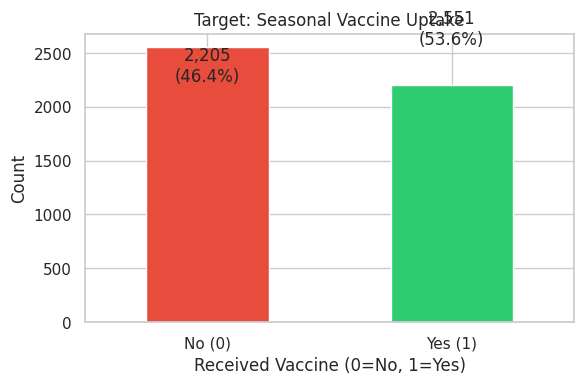

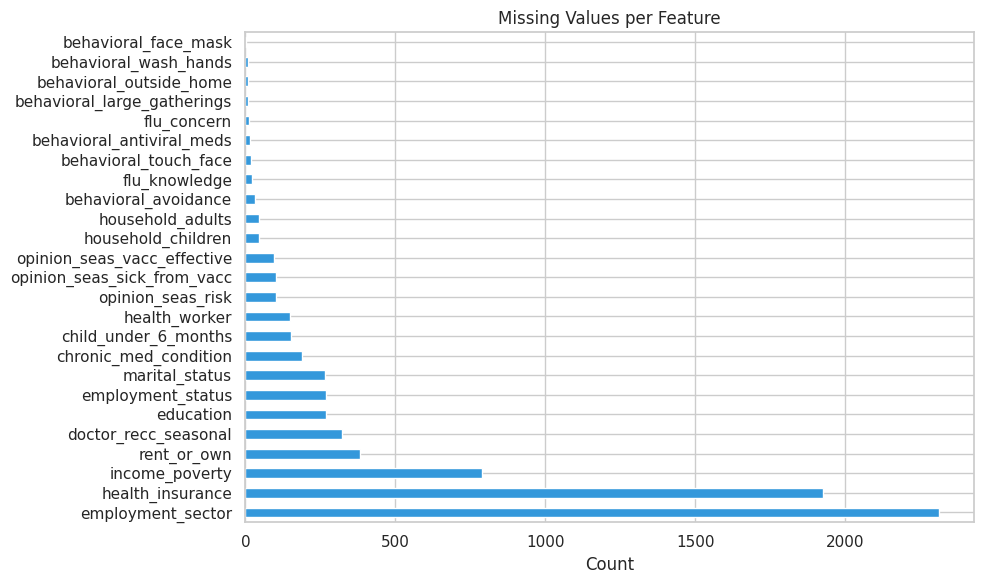

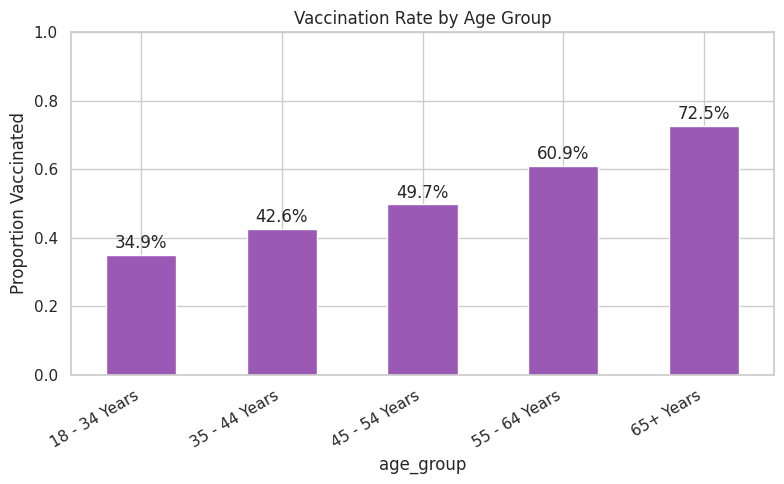

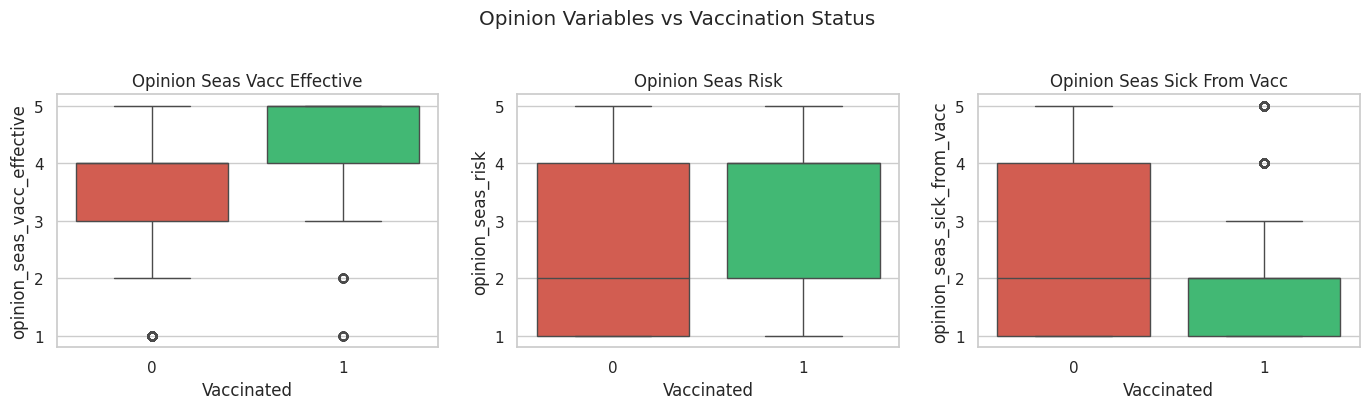

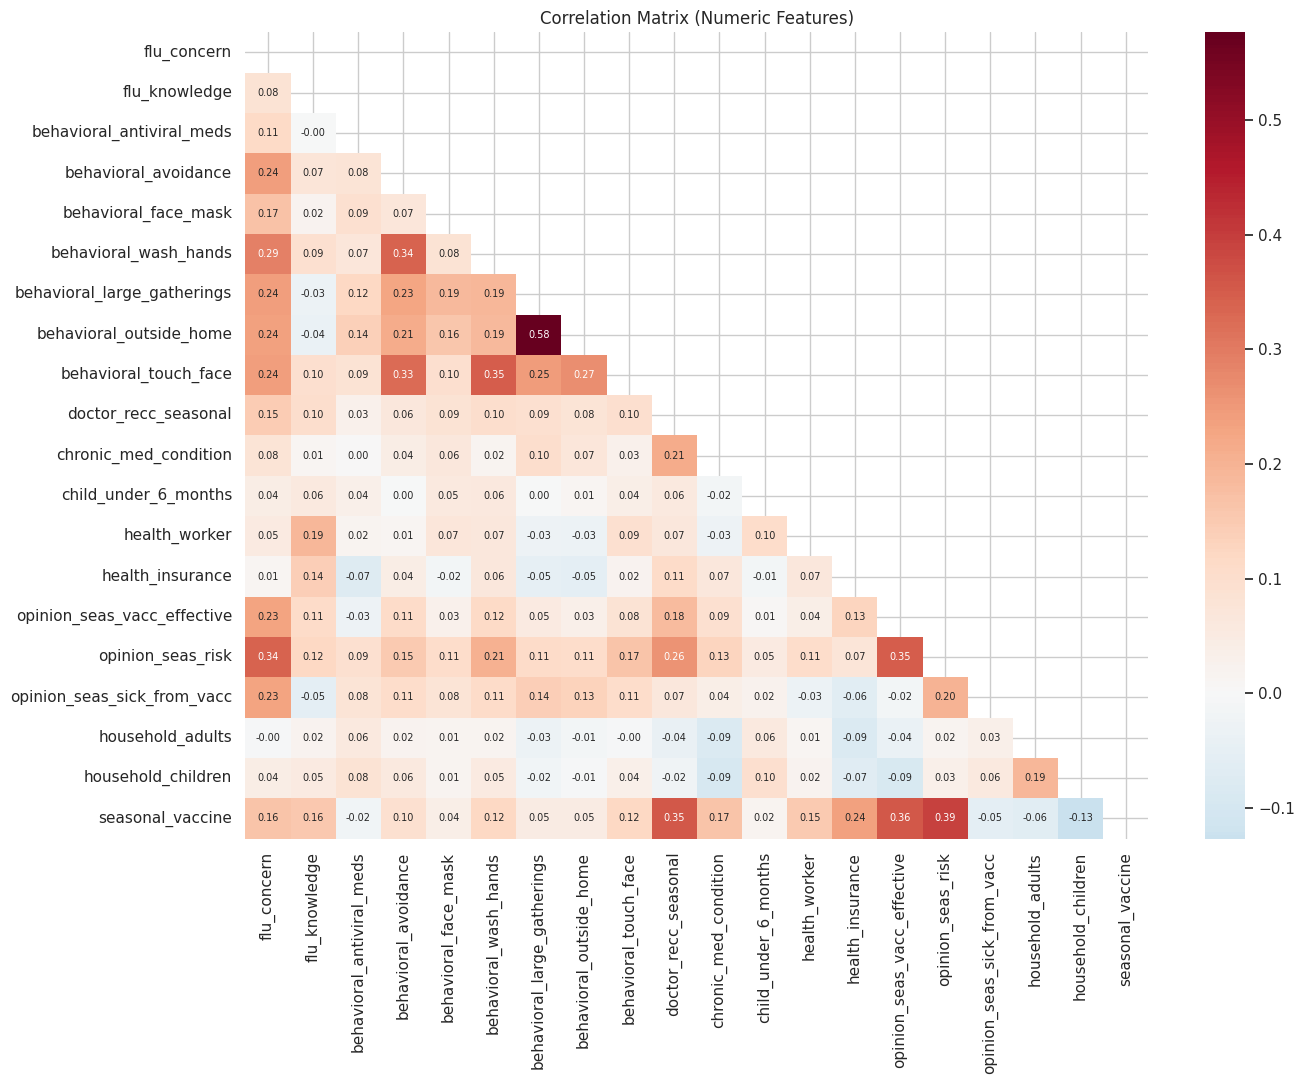

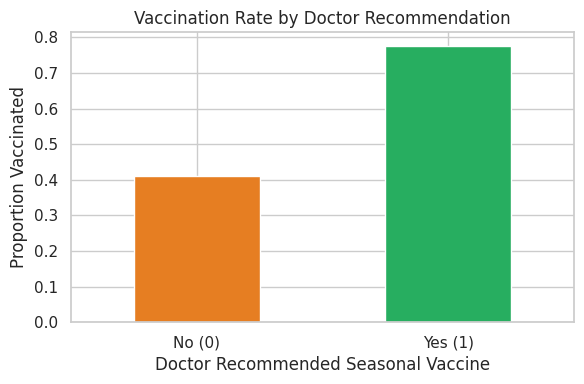

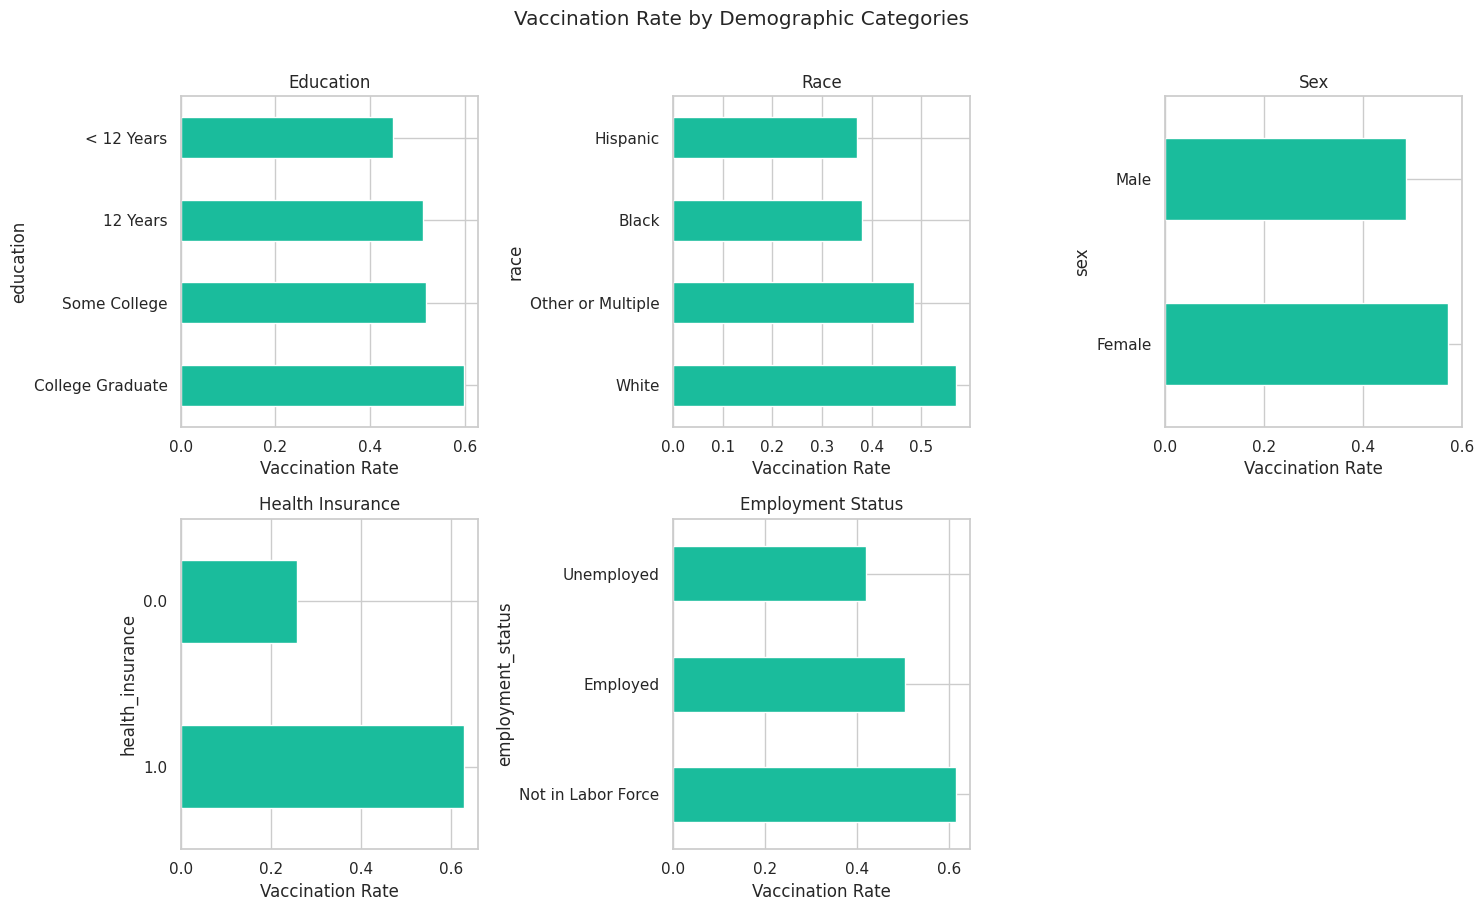

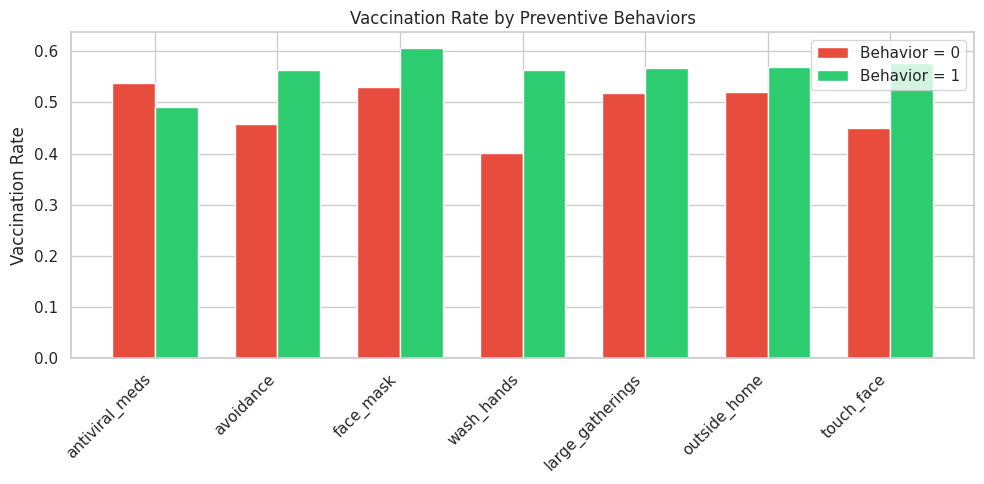

In [4]:
# 1. Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
train[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Target: Seasonal Vaccine Uptake")
ax.set_xlabel("Received Vaccine (0=No, 1=Yes)")
ax.set_ylabel("Count")
ax.set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
for i, v in enumerate(train[TARGET].value_counts().sort_index()):
    ax.text(i, v + 30, f"{v:,}\n({v/len(train):.1%})", ha="center")
plt.tight_layout()
plt.show()

# 2. Missing values
miss = train[feature_cols].isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(10, 6))
miss.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Missing Values per Feature")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

# 3. Vaccination rate by age group
fig, ax = plt.subplots(figsize=(8, 5))
age_order = ["18 - 34 Years", "35 - 44 Years", "45 - 54 Years", "55 - 64 Years", "65+ Years"]
age_vacc = train.groupby("age_group")[TARGET].mean().reindex(age_order)
age_vacc.plot(kind="bar", ax=ax, color="#9b59b6")
ax.set_title("Vaccination Rate by Age Group")
ax.set_ylabel("Proportion Vaccinated")
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(age_vacc):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

# 4. Opinion variables vs vaccination status
opinion_cols = ["opinion_seas_vacc_effective", "opinion_seas_risk", "opinion_seas_sick_from_vacc"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, opinion_cols):
    sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette=["#e74c3c", "#2ecc71"])
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Vaccinated")
plt.suptitle("Opinion Variables vs Vaccination Status", y=1.02)
plt.tight_layout()
plt.show()

# 5. Correlation heatmap (numeric features)
num_cols = train.select_dtypes(include=[np.number]).columns.drop(ID_COL)
corr = train[list(num_cols)].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

# 6. Vaccination rate by doctor recommendation
fig, ax = plt.subplots(figsize=(6, 4))
doc_vacc = train.groupby("doctor_recc_seasonal")[TARGET].mean()
doc_vacc.plot(kind="bar", ax=ax, color=["#e67e22", "#27ae60"])
ax.set_title("Vaccination Rate by Doctor Recommendation")
ax.set_xlabel("Doctor Recommended Seasonal Vaccine")
ax.set_ylabel("Proportion Vaccinated")
ax.set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
plt.tight_layout()
plt.show()

# 7. Vaccination rate by demographic categories
cat_cols = ["education", "race", "sex", "health_insurance", "employment_status"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    rates = train.groupby(col)[TARGET].mean().sort_values(ascending=False).head(6)
    rates.plot(kind="barh", ax=ax, color="#1abc9c")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Vaccination Rate")
for ax in axes[len(cat_cols):]:
    ax.axis("off")
plt.suptitle("Vaccination Rate by Demographic Categories", y=1.01)
plt.tight_layout()
plt.show()

# 8. Vaccination rate by preventive behaviors
beh_cols = [c for c in train.columns if c.startswith("behavioral_")]
beh_rates = pd.DataFrame({
    "feature": beh_cols,
    "rate_when_1": [train[train[c] == 1][TARGET].mean() for c in beh_cols],
    "rate_when_0": [train[train[c] == 0][TARGET].mean() for c in beh_cols],
})
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(beh_cols))
w = 0.35
ax.bar(x - w/2, beh_rates["rate_when_0"], w, label="Behavior = 0", color="#e74c3c")
ax.bar(x + w/2, beh_rates["rate_when_1"], w, label="Behavior = 1", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("behavioral_", "") for c in beh_cols], rotation=45, ha="right")
ax.set_ylabel("Vaccination Rate")
ax.set_title("Vaccination Rate by Preventive Behaviors")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Pre-processing

Four preprocessing options were compared using Gradient Boosting and 5-fold stratified ROC-AUC:

| Strategy | Main techniques | ROC-AUC |
|---|---|---|
| `scaled_numeric` | Median imputation + missing flags + scaling + Missing category + one-hot | 0.8532 ± 0.0027 |
| **`numeric_missing_indicators`** | **Median imputation + missing flags + Missing category + one-hot** | **0.8532 ± 0.0027** |
| `basic_median_mode` | Median numeric imputation + mode categorical imputation + one-hot | 0.8516 ± 0.0029 |
| `missing_category_onehot` | Median imputation + explicit Missing category + one-hot | 0.8509 ± 0.0028 |

**Selected preprocessing:** `numeric_missing_indicators` tied for best ROC-AUC without unnecessary scaling



In [5]:
X = train[feature_cols]
y = train[TARGET]

# Best preprocessing: numeric_missing_indicators
# - median imputation for numeric features + missing flags
# - explicit "Missing" category for categorical + one-hot encoding
preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

def get_feature_names(fitted_preprocessor):
    names = list(fitted_preprocessor.transformers_[0][2])
    numeric_transformer = fitted_preprocessor.named_transformers_["numeric"]
    if numeric_transformer.add_indicator:
        names.extend([
            f"{numeric_features[i]}_was_missing"
            for i in numeric_transformer.indicator_.features_
        ])
    cat_encoder = fitted_preprocessor.named_transformers_["categorical"].named_steps["encoder"]
    names.extend(cat_encoder.get_feature_names_out(categorical_features).tolist())
    return names

def make_gb_pipeline(**gb_params):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE, **gb_params)),
    ])

gb_pipe = make_gb_pipeline(n_estimators=150, learning_rate=0.05, max_depth=3)
gb_pipe.fit(X, y)

feature_names = get_feature_names(gb_pipe.named_steps["preprocessor"])
print("Preprocessing strategy: numeric_missing_indicators")
print(f"Features after preprocessing: {len(feature_names)}")


Preprocessing strategy: numeric_missing_indicators
Features after preprocessing: 93


## 3. Modelling — Gradient Boosting

Gradient Boosting is appropriate for this tabular survey dataset because it handles mixed feature types, non-linear relationships, and missingness patterns without requiring feature scaling.

## 4. Performance Analysis

**Metrics chosen (appropriate for binary classification with slight class imbalance):**
- **ROC-AUC** (primary) — measures how well the model ranks vaccinated vs non-vaccinated respondents; robust to imbalance
- **F1-score** — balances precision and recall for the positive class
- **Precision / Recall** — precision = correctness of positive predictions; recall = proportion of vaccinated respondents identified
- **Accuracy** — supplementary; can be misleading when classes are imbalanced
- **Confusion matrix** — shows false positives and false negatives

**Validation strategy (unseen data):**
1. **5-fold stratified cross-validation** on training data — each fold is held out while preserving class ratio
2. **20% hold-out validation set** — completely unseen during hyperparameter tuning
3. **Final retrain** on full training set for test-set submission

In [6]:
# 5-fold stratified cross-validation on unseen folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gb_pipe = make_gb_pipeline(n_estimators=150, learning_rate=0.05, max_depth=3)

scoring = {
    "Accuracy": "accuracy",
    "ROC-AUC": "roc_auc",
    "F1": "f1",
    "Precision": "precision",
    "Recall": "recall",
}

cv_results = []
for metric, scorer in scoring.items():
    scores = cross_val_score(gb_pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    cv_results.append({
        "Metric": metric,
        "Mean": scores.mean(),
        "Std": scores.std(),
        "Score": f"{scores.mean():.4f} ± {scores.std():.4f}",
    })

cv_df = pd.DataFrame(cv_results)
print("5-Fold Stratified Cross-Validation (Gradient Boosting):")
cv_df[["Metric", "Score"]]

5-Fold Stratified Cross-Validation (Gradient Boosting):


,Metric,Score
0,Accuracy,0.7794 ± 0.0035
1,ROC-AUC,0.8532 ± 0.0027
2,F1,0.7961 ± 0.0050
3,Precision,0.7894 ± 0.0057
4,Recall,0.8032 ± 0.0138


### 4.1 Hyperparameter Tuning

GridSearchCV searches over `n_estimators`, `max_depth`, and `learning_rate` using 3-fold CV on the training split, scored by ROC-AUC.

### 4.2 Hold-out Validation (20% unseen data)

Top 5 hyperparameter combinations:


,n_estimators,max_depth,learning_rate,ROC-AUC
1,150,3,0.05,0.8503 ± 0.0103
2,200,3,0.05,0.8501 ± 0.0102
9,100,3,0.10,0.8490 ± 0.0105
0,100,3,0.05,0.8489 ± 0.0102
10,150,3,0.10,0.8478 ± 0.0105



Best hyperparameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 150}
Best tuning CV ROC-AUC: 0.8503

Hold-out validation metrics (unseen 20% of training data):


,Metric,Score
0,Accuracy,0.7878
1,ROC-AUC,0.8551
2,F1,0.8058
3,Precision,0.7921
4,Recall,0.8200



Classification Report:
                precision    recall  f1-score   support

Not Vaccinated       0.78      0.75      0.77       441
    Vaccinated       0.79      0.82      0.81       511

      accuracy                           0.79       952
     macro avg       0.79      0.79      0.79       952
  weighted avg       0.79      0.79      0.79       952



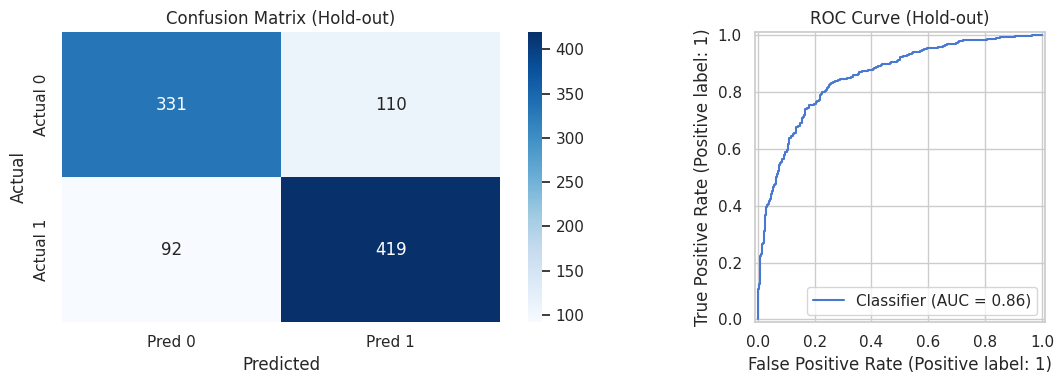

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(make_gb_pipeline(), param_grid, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

# Top 5 hyperparameter combinations
grid_results = pd.DataFrame(grid.cv_results_).sort_values("mean_test_score", ascending=False)
grid_results["ROC-AUC"] = grid_results.apply(
    lambda r: f"{r['mean_test_score']:.4f} ± {r['std_test_score']:.4f}", axis=1
)
print("Top 5 hyperparameter combinations:")
display(
    grid_results.head(5)[
        ["param_classifier__n_estimators", "param_classifier__max_depth",
         "param_classifier__learning_rate", "ROC-AUC"]
    ].rename(columns={
        "param_classifier__n_estimators": "n_estimators",
        "param_classifier__max_depth": "max_depth",
        "param_classifier__learning_rate": "learning_rate",
    })
)

print("\nBest hyperparameters:", grid.best_params_)
print(f"Best tuning CV ROC-AUC: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]

holdout_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC", "F1", "Precision", "Recall"],
    "Score": [
        accuracy_score(y_val, y_pred),
        roc_auc_score(y_val, y_proba),
        f1_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
    ],
})
holdout_metrics["Score"] = holdout_metrics["Score"].map(lambda x: f"{x:.4f}")
print("\nHold-out validation metrics (unseen 20% of training data):")
display(holdout_metrics)

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Not Vaccinated", "Vaccinated"]))

# Confusion matrix heatmap
cm = confusion_matrix(y_val, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
axes[0].set_title("Confusion Matrix (Hold-out)")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve (Hold-out)")
plt.tight_layout()
plt.show()

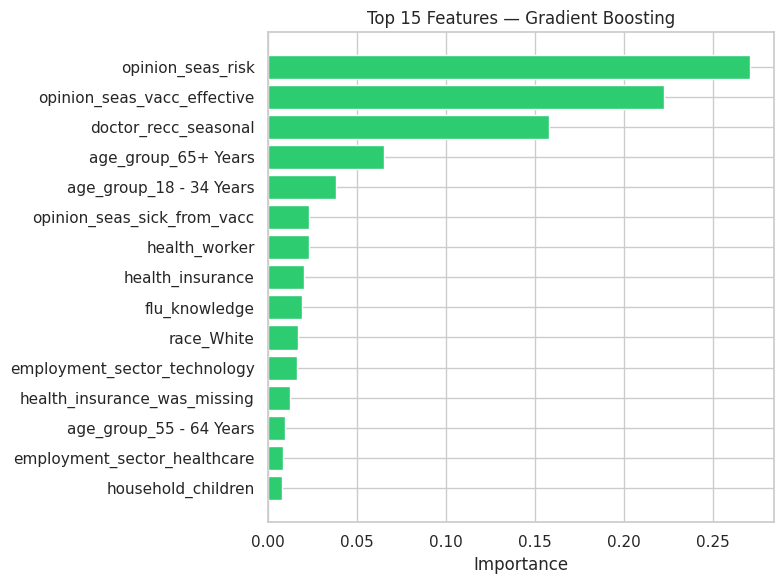

,feature,importance
15,opinion_seas_risk,0.270549
14,opinion_seas_vacc_effective,0.222090
9,doctor_recc_seasonal,0.157871
42,age_group_65+ Years,0.065271
38,age_group_18 - 34 Years,0.038335
16,opinion_seas_sick_from_vacc,0.023080
12,health_worker,0.022810
13,health_insurance,0.020425
1,flu_knowledge,0.019303
51,race_White,0.016923


In [8]:
feature_names = get_feature_names(best_model.named_steps["preprocessor"])
importances = best_model.named_steps["classifier"].feature_importances_

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#2ecc71")
ax.set_title("Top 15 Features — Gradient Boosting")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
imp_df


## 5. Critical Evaluation & Submission Decision

| Evaluation layer | Result | Interpretation |
|---|---|---|
| 5-fold CV ROC-AUC | ~0.853 | Stable generalisation across training folds |
| Hold-out ROC-AUC | ~0.855 | Confirms performance on completely unseen data |
| Hold-out F1 | ~0.806 | Good balance between precision and recall |
| Tuned hyperparameters | `n_estimators=150`, `max_depth=3`, `learning_rate=0.05` | Shallow trees with moderate ensemble size generalise best |

## 6. Final Training & Submission

In [9]:
# Retrain tuned model on full training data
final_model = make_gb_pipeline(**{k.replace("classifier__", ""): v for k, v in grid.best_params_.items()})
final_model.fit(X, y)

test_preds = final_model.predict(test[feature_cols])
submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: test_preds.astype(float)})
submission.to_csv("submission.csv", index=False)

print(f"Predictions saved to submission.csv ({len(submission)} rows)")
print(submission[TARGET].value_counts())
submission.head()

Predictions saved to submission.csv (4749 rows)
seasonal_vaccine
1.0    2711
0.0    2038
Name: count, dtype: int64


,respondent_id,seasonal_vaccine
0,4757,1.0
1,4758,1.0
2,4759,1.0
3,4760,1.0
4,4761,0.0
